In [3]:
!pip install keras-tuner

import numpy as np
import keras
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.utils import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.layers import Dense, Input, Embedding, Flatten
from keras.models import Sequential
from keras.layers import Flatten
import keras_tuner
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, auc, roc_curve, precision_recall_curve
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, label_binarize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.3 MB/s eta 0:00:00


In [28]:
corpus=[]
dic_diag={}
dic_proc={}
dic_grd={}
archivo=open("dataset_elpino.csv",encoding="utf-8")

#Sacar las variables (features o característica)
header=archivo.readline().strip().split(";")
features=[]
for col in header:
    if col.startswith("Diag") or col.startswith("Proc"):
        col=col.split(" ")
        col=col[0]+col[1]
    features.append(col)

#Sacar la data (deja sólo los códigos en el corpus y en diccionario las descripciones)
for linea in archivo:
    row=[]
    linea=linea.strip().split(";")
    for i in range(len(linea)):
        cod=linea[i].split("-")[0].strip()
        if len(linea[i].split("-")) == 2:
            des=linea[i].split("-")[1].strip()
        if i < 35:
            dic_diag[cod]=des
        elif i < 65:
            dic_proc[cod]=des
        elif i == 67:
            dic_grd[cod]=des
        elif i==66:
            cod = 1 if cod=="Mujer" else 0
        row.append(cod)
    corpus.append(row)

#Crear un dataframe con la data
df = pd.DataFrame(corpus, columns=features)
df.head(20)

,Diag01,Diag02,Diag03,Diag04,Diag05,Diag06,Diag07,Diag08,Diag09,Diag10,...,Proced24,Proced25,Proced26,Proced27,Proced28,Proced29,Proced30,Edad en años,Sexo (Desc),GRD
0,A41.8,B37.6,I39.8,N10,B96.1,L89.9,L08.9,B96.2,A41.5,J86.9,...,99.84,88.72,90.42,90.52,91.39,91.33,87.03,40,0,184103
1,U07.1,J12.8,R06.0,R05,R50.9,Z29.0,Z01.7,J96.00,J94.2,J92.9,...,91.62,90.43,91.39,90.52,91.32,96.59,90.99,53,0,041013
2,K56.5,R57.2,R57.1,J80,Y95,J15.0,U82.2,B95.6,B96.8,B37.1,...,99.84,91.73,90.53,99.26,89.39,89.66,89.65,65,0,041013
3,K76.8,K66.1,N18.5,D64.9,E87.5,E87.2,J81,N17.8,J44.9,R41.0,...,57.94,00.13,00.17,99.04,99.18,99.21,99.23,61,0,041023
4,T81.0,Y83.2,S31.1,S36.80,W31.62,J96.09,J15.0,U82.2,U07.1,N39.0,...,90.52,91.39,91.32,93.90,99.15,96.59,45.13,30,0,041023
5,U07.1,J12.8,R06.0,R50.9,R53,R05,Z29.0,Z01.7,J96.00,J80,...,57.94,00.17,89.39,96.6,99.26,91.82,90.99,49,1,041013
6,U07.1,J12.8,R06.0,R05,Z29.0,Z01.7,J96.09,J80,J15.1,A41.8,...,91.32,99.18,93.94,99.21,00.17,99.29,99.19,55,0,041013
7,U07.1,J12.8,J96.09,J80,R06.0,R50.9,R05,M79.19,Z29.0,Z01.7,...,99.17,99.18,99.19,99.21,99.23,99.26,99.29,33,1,041013
8,U07.1,J12.8,J80,Z20.8,Z29.0,Z01.7,T81.4,Y83.6,K85.9,K65.0,...,99.04,99.18,99.19,99.21,99.26,99.29,93.01,37,1,041023
9,U07.1,J12.8,J96.00,R50.9,R11,R05,M79.19,R07.0,A09.9,Z29.0,...,99.26,99.29,93.01,93.09,93.11,93.12,93.13,59,0,041023


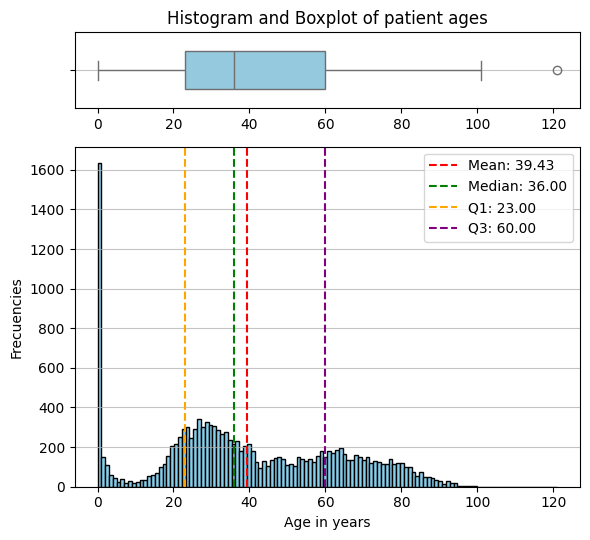

In [8]:
# Calcular estadísticas
q1 = df['Edad en años'].astype(int).quantile(0.25)
q3 = df['Edad en años'].astype(int).quantile(0.75)
iqr = q3 - q1
media = df['Edad en años'].astype(int).mean()
mediana = df['Edad en años'].astype(int).median()

# Crear una figura con subgráficos
fig, axes = plt.subplots(2, 1, gridspec_kw={'height_ratios': [1, 4.5]}, figsize=(6, 5.5))

# Diagrama de caja
sns.boxplot(x=df['Edad en años'].astype(int), showfliers=True, color='skyblue', ax=axes[0], width=0.5)
axes[0].set_title('Histogram and Boxplot of patient ages')
axes[0].grid(axis='y', alpha=0.75)
axes[0].set_xlabel('')

# Histograma
axes[1].hist([int(i) for i in df['Edad en años']], bins=120, color='skyblue', edgecolor='black')
axes[1].axvline(media, color='red', linestyle='--', label=f'Mean: {media:.2f}')
axes[1].axvline(mediana, color='green', linestyle='--', label=f'Median: {mediana:.2f}')
axes[1].axvline(q1, color='orange', linestyle='--', label=f'Q1: {q1:.2f}')
axes[1].axvline(q3, color='purple', linestyle='--', label=f'Q3: {q3:.2f}')
axes[1]
axes[1].set_xlabel('Age in years')
axes[1].set_ylabel('Frecuencies')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.75)

# Ajustar el diseño
plt.tight_layout()
plt.show()

In [9]:
df = df[df['Edad en años'].astype(int) <= 120]

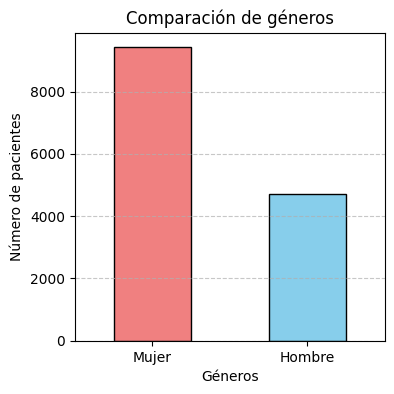

In [21]:
# Calcular la frecuencia absoluta por género
frecuencia_genero = df['Sexo (Desc)'].value_counts()

# Renombrar las etiquetas (opcional)
frecuencia_genero.index = ['Mujer', 'Hombre']

# Crear gráfico de barras
plt.figure(figsize=(4, 4))
frecuencia_genero.plot(kind='bar', color=['lightcoral', 'skyblue'], edgecolor='black')
plt.title('Comparación de géneros')
plt.xlabel('Géneros')
plt.ylabel('Número de pacientes')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Con las primeras 119 clases se acumula ≤80% de instancias. Con 120 clases se supera el 80%.


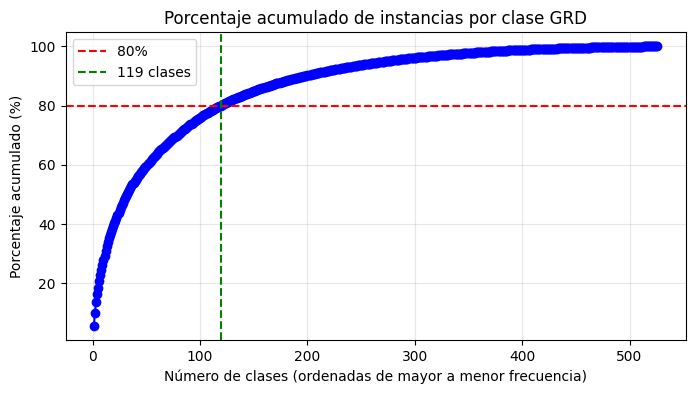

In [12]:
# Contar la cantidad de instancias por clase en la columna GRD
cantidad_por_clase = df['GRD'].value_counts()

# Calcular frecuencia por clase y orden descendente
freq = df['GRD'].value_counts()
cumsum_perc = freq.cumsum() / freq.sum() * 100

# Encontrar índice donde se supera el 80%
idx_80 = (cumsum_perc <= 80).sum()  # número de clases que suman hasta 80% (sin contar la que lo supera)
print(f"Con las primeras {idx_80} clases se acumula ≤80% de instancias. Con {idx_80+1} clases se supera el 80%.")

# Gráfico de porcentaje acumulado
plt.figure(figsize=(8,4))
plt.plot(range(1, len(cumsum_perc)+1), cumsum_perc, marker='o', linestyle='-', color='blue')
plt.axhline(y=80, color='red', linestyle='--', label='80%')
plt.axvline(x=idx_80, color='green', linestyle='--', label=f'{idx_80} clases')
plt.title('Porcentaje acumulado de instancias por clase GRD')
plt.xlabel('Número de clases (ordenadas de mayor a menor frecuencia)')
plt.ylabel('Porcentaje acumulado (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
# Filtrar las clases con al menos 5 instancias
clases_con_suficientes_instancias = df['GRD'].value_counts()[df['GRD'].value_counts() >= 5].index
df = df[df['GRD'].isin(clases_con_suficientes_instancias)]

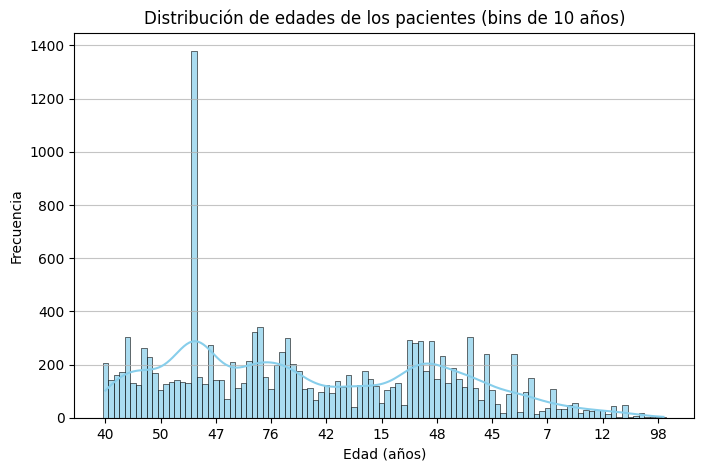

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Definir los límites de los bins cada 10 años (de 0 a 100, ajusta según tus datos)
bins_10 = np.arange(0, 101, 10)

plt.figure(figsize=(8, 5))
sns.histplot(df['Edad en años'], bins=bins_10, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de edades de los pacientes (bins de 10 años)')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.xticks(bins_10)
plt.grid(axis='y', alpha=0.75)
plt.show()

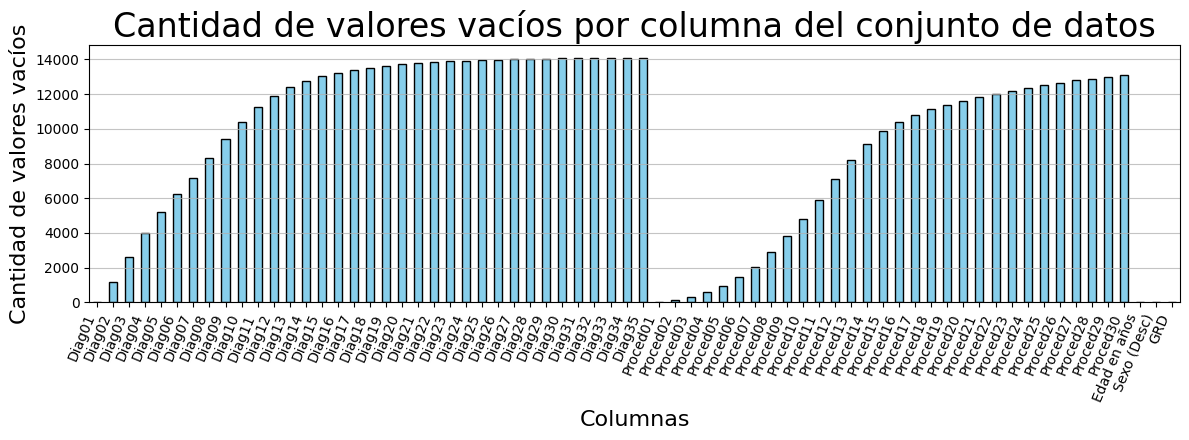

In [20]:
# Calcular la cantidad de valores '' en las primeras 80 columnas
valores_vacios_str = (df.iloc[:, :80] == '').sum()

# Crear el gráfico de barras
plt.figure(figsize=(12, 4.5))
valores_vacios_str.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Cantidad de valores vacíos por columna del conjunto de datos', fontsize=24)
plt.xticks(rotation=22.5+45, ha='right')
plt.xlabel('Columnas', fontsize=16)
plt.ylabel('Cantidad de valores vacíos', fontsize=16)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Ensure 'Edad en años' is numeric, handling potential errors
df['Edad en años'] = pd.to_numeric(df['Edad en años'], errors='coerce')

# Drop rows where 'Edad en años' is NaN after conversion, or if previous filtering steps created NaNs
df.dropna(subset=['Edad en años'], inplace=True)

# Define target variable
y = df['Edad en años']

# Define features: 'Sexo (Desc)' and 'GRD'
X_features = df[['Sexo (Desc)', 'GRD']].copy()

# One-hot encode 'GRD' column
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
grd_encoded = encoder.fit_transform(X_features[['GRD']])
grd_encoded_df = pd.DataFrame(grd_encoded, columns=encoder.get_feature_names_out(['GRD']), index=X_features.index)

# Combine 'Sexo (Desc)' with the one-hot encoded 'GRD'
X_processed = pd.concat([X_features[['Sexo (Desc)']], grd_encoded_df], axis=1)

# Ensure X_processed and y have aligned indices after any row drops
X_processed, y = X_processed.align(y, join='inner', axis=0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Linear Regression Model Results ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


--- Linear Regression Model Results ---
Mean Squared Error (MSE): 282.43
Root Mean Squared Error (RMSE): 16.81
R-squared (R2): 0.55


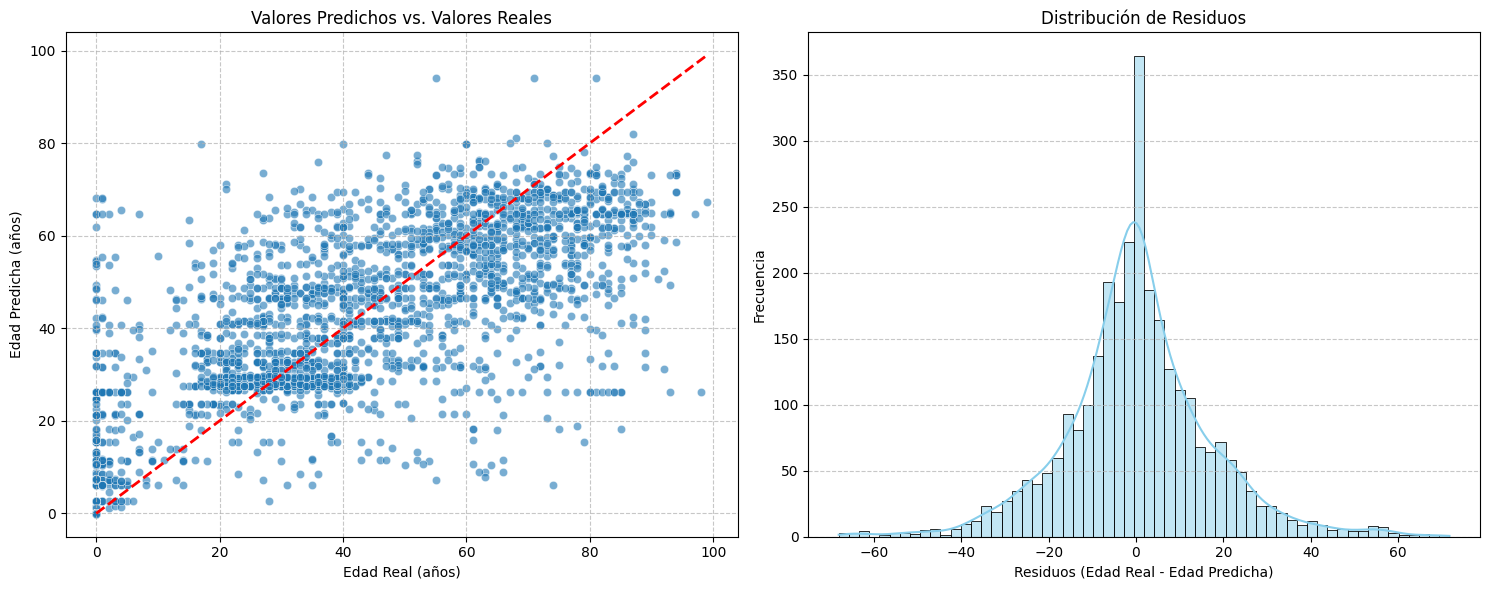

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(15, 6))

# Subplot 1: Predicted vs. Actual Values
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.title('Valores Predichos vs. Valores Reales')
plt.xlabel('Edad Real (años)')
plt.ylabel('Edad Predicha (años)')
plt.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Residuals Distribution
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribución de Residuos')
plt.xlabel('Residuos (Edad Real - Edad Predicha)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [51]:
seed = 12122008
X = []
Y = []

le = LabelEncoder()
for column in df.columns[:-1]:
    df[column] = le.fit_transform(df[column].astype(str))
X = df.iloc[:, :-1].values

ohe = OneHotEncoder(sparse_output=False)
Y = ohe.fit_transform(df['GRD'].values.reshape(-1, 1))

In [52]:
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=seed, stratify=Y)

In [53]:
def build_model(hp):
    modelo = Sequential()
    modelo.add(Input(shape=(X.shape[1],)))
    for i in range(hp.Choice("capas", [1, 2, 3])):
        modelo.add(Dense(hp.Choice("neuronas_capa", [8, 16, 32, 64]), activation="relu"))
    modelo.add(Dense(y_train.shape[1], activation="softmax"))
    modelo.compile(
        loss="categorical_crossentropy",
        metrics=[tf.keras.metrics.CategoricalAccuracy(name="acc")],
        optimizer="adam"
    )
    return modelo

tuner=keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective=keras_tuner.Objective("val_acc",direction="max"),
    max_trials=16,
    executions_per_trial=1,
    overwrite=True,
    directory="modelos",
    project_name="GRD"
)

In [54]:
tuner.search(x_train,y_train,epochs=16,validation_data=(x_val,y_val),batch_size=32,verbose=1)

Trial 11 Complete [00h 00m 21s]
val_acc: 0.0883672758936882

Best val_acc So Far: 0.2633759081363678
Total elapsed time: 00h 04m 32s


In [55]:
mejor_modelo=tuner.get_best_models()[0]
mejor_modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 450)            │        14,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,138 (74.76 KB)

 Trainable params: 19,138 (74.76 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
modelo=Sequential()
modelo.add(Input(shape=(X.shape[1],)))
modelo.add(Dense(64))
modelo.add(Dense(64))
modelo.add(Dense(64))
modelo.add(Dense(Y.shape[1],activation="softmax"))
modelo.compile(optimizer="Adam",loss="categorical_crossentropy",metrics=["acc"])
modelo.fit(x_train, y_train, epochs=50, batch_size=32, verbose=2)

Epoch 1/50
363/363 - 2s - 6ms/step - acc: 0.0780 - loss: 46.3695
Epoch 2/50
363/363 - 1s - 3ms/step - acc: 0.1307 - loss: 10.5419
Epoch 3/50
363/363 - 1s - 3ms/step - acc: 0.1628 - loss: 6.5991
Epoch 4/50
363/363 - 1s - 4ms/step - acc: 0.1767 - loss: 5.3548
Epoch 5/50
363/363 - 1s - 4ms/step - acc: 0.1917 - loss: 4.6963
Epoch 6/50
363/363 - 1s - 3ms/step - acc: 0.2055 - loss: 4.3408
Epoch 7/50
363/363 - 1s - 3ms/step - acc: 0.2192 - loss: 4.1293
Epoch 8/50
363/363 - 1s - 3ms/step - acc: 0.2224 - loss: 3.9526
Epoch 9/50
363/363 - 1s - 3ms/step - acc: 0.2282 - loss: 3.8329
Epoch 10/50
363/363 - 1s - 3ms/step - acc: 0.2343 - loss: 3.7701
Epoch 11/50
363/363 - 1s - 4ms/step - acc: 0.2378 - loss: 3.7077
Epoch 12/50
363/363 - 1s - 3ms/step - acc: 0.2295 - loss: 3.6674
Epoch 13/50
363/363 - 1s - 3ms/step - acc: 0.2377 - loss: 3.6303
Epoch 14/50
363/363 - 1s - 3ms/step - acc: 0.2473 - loss: 3.5882
Epoch 15/50
363/363 - 2s - 4ms/step - acc: 0.2439 - loss: 3.5815
Epoch 16/50
363/363 - 1s - 4ms/s

In [58]:
y_pred_probs=modelo.predict(x_val)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


[239 192 377 ... 374 192 347]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ran

Rec=0.05 Acc=0.25 Pre=0.05


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


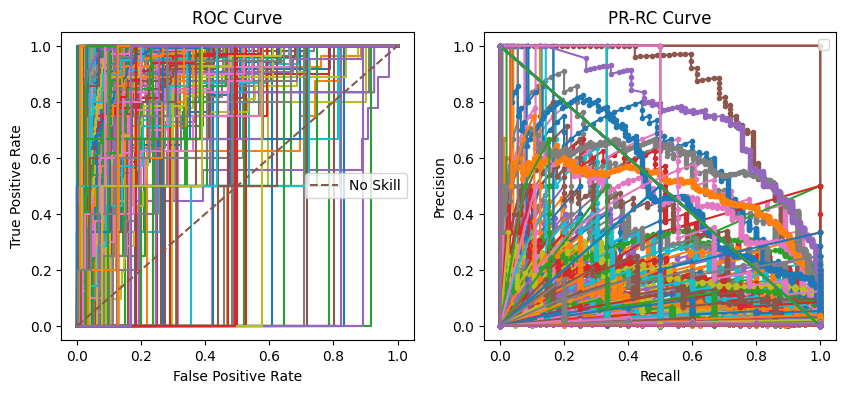

In [59]:
y_pred = np.argmax(y_pred_probs, axis=1)
y_val_classes = np.argmax(y_val, axis=1)

print(y_pred)

fig, axes = plt.subplots(1, 2)
fig.set_size_inches(10, 4)

roc_aucs = []



# ROC Curve (requiere binarización para multiclase)
y_val_binarized = label_binarize(y_val_classes, classes=range(len(np.unique(y_val_classes))))
fpr = {}
tpr = {}
roc_auc = {}
for i in range(y_val_binarized.shape[1]):
    fpr[i], tpr[i], _ = roc_curve(y_val_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve para cada clase
for i in range(len(roc_auc)):
    axes[0].plot(fpr[i], tpr[i])#, label=f'Class {i} (area = {roc_auc[i]:0.2f})')
axes[0].plot([0, 1], [0, 1], '--', label='No Skill')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall Curve
lr_precision = {}
lr_recall = {}
pr_auc = {}
for i in range(y_val_binarized.shape[1]):
    lr_precision[i], lr_recall[i], _ = precision_recall_curve(y_val_binarized[:, i], y_pred_probs[:, i])
    pr_auc[i] = auc(lr_recall[i], lr_precision[i])

# Plot Precision-Recall Curve para cada clase
for i in range(len(pr_auc)):
    axes[1].plot(lr_recall[i], lr_precision[i], marker='.')#, label=f'Class {i} (area = {pr_auc[i]:0.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR-RC Curve')
axes[1].legend()

print("Rec=" + str(round(recall_score(y_val_classes, y_pred, average='macro'), 2)) +
              " Acc=" + str(round(accuracy_score(y_val_classes, y_pred), 2)) +
              " Pre=" + str(round(precision_score(y_val_classes, y_pred, average='macro'), 2)))

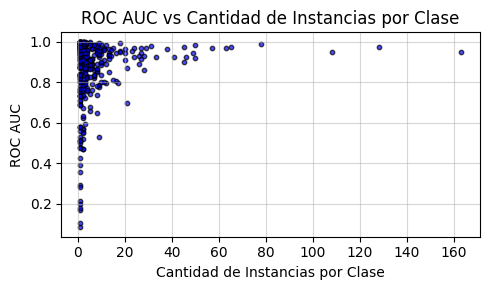

In [60]:
cantidad_instancias = np.sum(y_val_binarized, axis=0)

# Extraer los valores de roc_auc
roc_values = list(roc_auc.values())

# Crear el gráfico
plt.figure(figsize=(5, 3))
plt.scatter(cantidad_instancias, roc_values, color='blue', alpha=0.7, edgecolor='black', s=10)
plt.title('ROC AUC vs Cantidad de Instancias por Clase')
plt.xlabel('Cantidad de Instancias por Clase')
plt.ylabel('ROC AUC')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

In [61]:
columnas_sin_vacios = valores_vacios_str[valores_vacios_str == 0].index.tolist()
columnas_sin_vacios.remove('GRD')

# Ordenar las columnas restantes por cantidad de valores vacíos
columnas_con_vacios = valores_vacios_str[valores_vacios_str > 0].sort_values().index.tolist()

# Combinar las columnas en el orden deseado
columnas_ordenadas = columnas_sin_vacios + columnas_con_vacios

# Crear un diccionario para mapear los diagnósticos y procedimientos a sus valores codificados
diccionario_labelencode = {}
X_optimo = df[columnas_ordenadas]
# Iterar sobre las columnas seleccionadas y sus valores únicos
for columna in X_optimo.columns:
    le = LabelEncoder()
    le.fit(X_optimo[columna])
    diccionario_labelencode[columna] = dict(zip(le.classes_, le.transform(le.classes_)))

# Función para obtener el LabelEncode de un diagnóstico o procedimiento
def obtener_labelencode(columna, valor):
    return diccionario_labelencode.get(columna, {}).get(valor, "Valor no encontrado")

# Ejemplo de uso
print(diccionario_labelencode)

{'Diag01': {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5), np.int64(6): np.int64(6), np.int64(7): np.int64(7), np.int64(8): np.int64(8), np.int64(9): np.int64(9), np.int64(10): np.int64(10), np.int64(11): np.int64(11), np.int64(12): np.int64(12), np.int64(13): np.int64(13), np.int64(14): np.int64(14), np.int64(15): np.int64(15), np.int64(16): np.int64(16), np.int64(17): np.int64(17), np.int64(18): np.int64(18), np.int64(19): np.int64(19), np.int64(20): np.int64(20), np.int64(21): np.int64(21), np.int64(22): np.int64(22), np.int64(23): np.int64(23), np.int64(24): np.int64(24), np.int64(25): np.int64(25), np.int64(26): np.int64(26), np.int64(27): np.int64(27), np.int64(28): np.int64(28), np.int64(29): np.int64(29), np.int64(30): np.int64(30), np.int64(31): np.int64(31), np.int64(32): np.int64(32), np.int64(33): np.int64(33), np.int64(34): np.int64(34), np.int64(35): np.int64(35), 

In [62]:
X_optimo_encoded = X_optimo.copy()
for column in X_optimo_encoded.columns:
    le = LabelEncoder()
    X_optimo_encoded[column] = le.fit_transform(X_optimo_encoded[column].astype(str))  # Convertir a str si es necesario

X_optimo_encoded = np.asarray(X_optimo_encoded)
Y = np.asarray(Y)

print("X_optimo_encoded shape:", X_optimo_encoded.shape)
print("Y shape:", Y.shape)

# Definir el vocabulario como el número de valores únicos en X_optimo_encoded
vocabulary = len(np.unique(X_optimo_encoded))
print("Vocabulario:", vocabulary)

X_optimo_encoded shape: (14485, 67)
Y shape: (14485, 450)
Vocabulario: 1698


In [63]:
resultados_incrementales = []
# Obtener las columnas sin valores vacíos
columnas_sin_vacios = valores_vacios_str[valores_vacios_str == 0].index.tolist()
columnas_sin_vacios.remove('GRD')

# Ordenar las columnas restantes por cantidad de valores vacíos
columnas_con_vacios = valores_vacios_str[valores_vacios_str > 0].sort_values().index.tolist()

# Combinar las columnas en el orden deseado
columnas_ordenadas = columnas_sin_vacios + columnas_con_vacios

# Iterar sobre el número de columnas a incluir
for i in range(1, len(columnas_ordenadas) + 1):
    print(f"Entrenando modelo con {i} columnas...")
    columnas_seleccionadas = df[columnas_ordenadas[:i]].apply(LabelEncoder().fit_transform).values
    # Dividir los datos en entrenamiento y validación
    x_train_inc, x_val_inc, y_train_inc, y_val_inc = train_test_split(
        columnas_seleccionadas, Y, test_size=0.2, random_state=seed, stratify=Y
    )

    # Crear y entrenar el modelo
    modelo = Sequential()
    modelo.add(Embedding(input_dim=vocabulary, output_dim= 128))
    modelo.add(Flatten())
    modelo.add(Dense(32, activation="relu"))
    modelo.add(Dense(32, activation="relu"))
    modelo.add(Dense(32, activation="relu"))
    modelo.add(Dense(Y.shape[1], activation="softmax"))
    modelo.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    modelo.fit(x_train_inc, y_train_inc, epochs=16, batch_size=32, verbose=0)

    # Evaluar el modelo
    loss, accuracy = modelo.evaluate(x_val_inc, y_val_inc, verbose=0)
    resultados_incrementales.append({"columnas": i, "accuracy": accuracy})

# Mostrar los resultados
resultados_incrementales_df = pd.DataFrame(resultados_incrementales)
print(resultados_incrementales_df)

Entrenando modelo con 1 columnas...
Entrenando modelo con 2 columnas...
Entrenando modelo con 3 columnas...
Entrenando modelo con 4 columnas...
Entrenando modelo con 5 columnas...
Entrenando modelo con 6 columnas...
Entrenando modelo con 7 columnas...
Entrenando modelo con 8 columnas...
Entrenando modelo con 9 columnas...
Entrenando modelo con 10 columnas...
Entrenando modelo con 11 columnas...
Entrenando modelo con 12 columnas...
Entrenando modelo con 13 columnas...
Entrenando modelo con 14 columnas...
Entrenando modelo con 15 columnas...
Entrenando modelo con 16 columnas...
Entrenando modelo con 17 columnas...
Entrenando modelo con 18 columnas...
Entrenando modelo con 19 columnas...
Entrenando modelo con 20 columnas...
Entrenando modelo con 21 columnas...
Entrenando modelo con 22 columnas...
Entrenando modelo con 23 columnas...
Entrenando modelo con 24 columnas...
Entrenando modelo con 25 columnas...
Entrenando modelo con 26 columnas...
Entrenando modelo con 27 columnas...
Entrenando

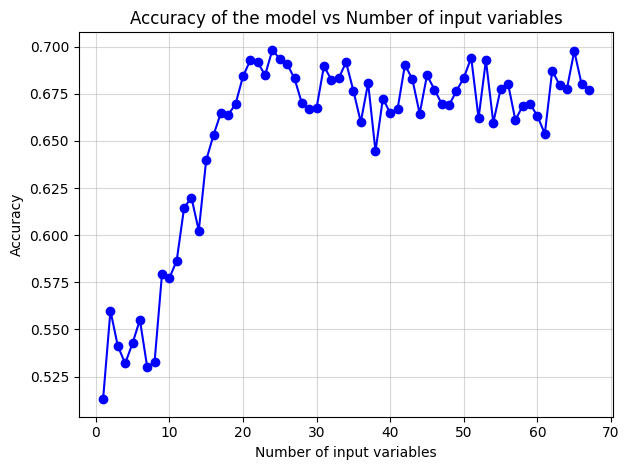

In [64]:
plt.plot(resultados_incrementales_df["columnas"], resultados_incrementales_df["accuracy"], marker="o", color="blue")
plt.title("Accuracy of the model vs Number of input variables")
plt.xlabel("Number of input variables")
plt.ylabel("Accuracy")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

In [65]:
print(resultados_incrementales_df.iloc[5])
print(resultados_incrementales_df.iloc[-1])
print(resultados_incrementales_df.iloc[30])

columnas    6.000000
accuracy    0.555057
Name: 5, dtype: float64
columnas    67.000000
accuracy     0.676907
Name: 66, dtype: float64
columnas    31.000000
accuracy     0.689679
Name: 30, dtype: float64


In [66]:
vocabulary = 10000

def build_model(hp):
    modelo = Sequential()
    modelo.add(Embedding(input_dim=vocabulary, output_dim=hp.Choice("embedding_dim", [8, 16, 32, 64, 128])))
    modelo.add(Flatten())
    modelo.add(Dense(64, activation="relu"))
    modelo.add(Dense(64, activation="relu"))
    modelo.add(Dense(64, activation="relu"))
    modelo.add(Dense(Y.shape[1], activation="softmax"))
    modelo.compile(
        loss="categorical_crossentropy",
        metrics=[tf.keras.metrics.CategoricalAccuracy(name="acc")],
        optimizer="adam"
    )
    return modelo

In [67]:
tuner=keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective=keras_tuner.Objective("val_acc",direction="max"),
    max_trials=32,
    executions_per_trial=1,
    overwrite=True,
    directory="modelos",
    project_name="reprobacion"
)

In [68]:
tuner.search_space_summary()

Search space summary
Default search space size: 1
embedding_dim (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32, 64, 128], 'ordered': True}


In [69]:
len(y_train[0])

450

In [70]:
x_train, x_val, y_train, y_val = train_test_split(X_optimo_encoded[:,:31], Y, test_size=0.2, stratify=Y, random_state=seed)

In [71]:
tuner.search(x_train,y_train,epochs=16,validation_data=(x_val,y_val),batch_size=32,verbose=1)

Trial 5 Complete [00h 02m 08s]
val_acc: 0.7183293104171753

Best val_acc So Far: 0.7183293104171753
Total elapsed time: 00h 05m 32s


In [72]:
mejor_modelo=tuner.get_best_models()[0]
mejor_modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 31, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3968)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       254,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 450)            │        29,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,571,586 (6.00 MB)

 Trainable params: 1,571,586 (6.00 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
y_pred_probs=mejor_modelo.predict(x_val)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [74]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc

import seaborn as sns
from sklearn.preprocessing import label_binarize

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ran

Rec=0.39 Acc=0.72 Pre=0.38


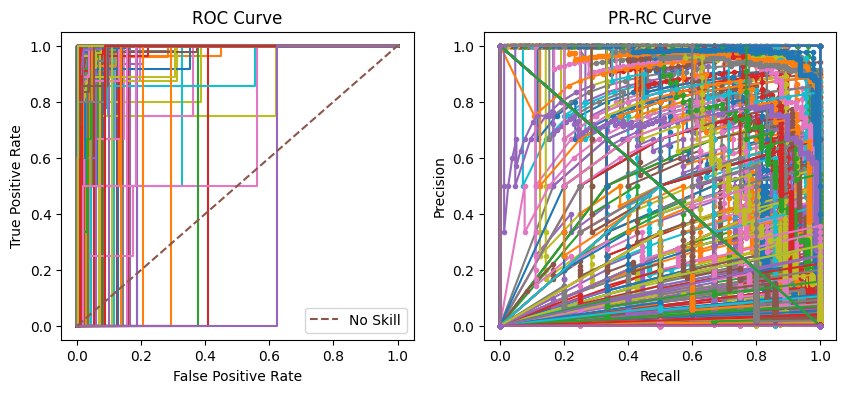

In [75]:
# Para multiclase, selecciona la clase con la mayor probabilidad
y_pred = np.argmax(y_pred_probs, axis=1)
y_val_classes = np.argmax(y_val, axis=1)  # Convertir one-hot encoding a clases


fig, axes = plt.subplots(1, 2)
fig.set_size_inches(10, 4)

roc_aucs = []

# # Matriz de confusión
# matriz = confusion_matrix(y_val_classes, y_pred)
# ax = axes[0]
# sns.heatmap(matriz, annot=True, ax=ax, cmap="Blues", fmt="d")
# ax.set_title("Rec=" + str(round(recall_score(y_val_classes, y_pred, average='macro'), 2)) +
#              " Acc=" + str(round(accuracy_score(y_val_classes, y_pred), 2)) +
#              " Pre=" + str(round(precision_score(y_val_classes, y_pred, average='macro'), 2)))
# axes[0].set_xlabel('Predicted')
# axes[0].set_ylabel('Real')

# ROC Curve (requiere binarización para multiclase)
y_val_binarized = label_binarize(y_val_classes, classes=range(len(np.unique(y_val_classes))))
fpr = {}
tpr = {}
roc_auc = {}
for i in range(y_val_binarized.shape[1]):
    fpr[i], tpr[i], _ = roc_curve(y_val_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve para cada clase
for i in range(len(roc_auc)):
    axes[0].plot(fpr[i], tpr[i])#, label=f'Class {i} (area = {roc_auc[i]:0.2f})')
axes[0].plot([0, 1], [0, 1], '--', label='No Skill')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall Curve
lr_precision = {}
lr_recall = {}
pr_auc = {}
for i in range(y_val_binarized.shape[1]):
    lr_precision[i], lr_recall[i], _ = precision_recall_curve(y_val_binarized[:, i], y_pred_probs[:, i])
    pr_auc[i] = auc(lr_recall[i], lr_precision[i])

# Plot Precision-Recall Curve para cada clase
for i in range(len(pr_auc)):
    axes[1].plot(lr_recall[i], lr_precision[i], marker='.')#, label=f'Class {i} (area = {pr_auc[i]:0.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR-RC Curve')

print("Rec=" + str(round(recall_score(y_val_classes, y_pred, average='macro',zero_division=0), 2)) +
              " Acc=" + str(round(accuracy_score(y_val_classes, y_pred), 2)) +
              " Pre=" + str(round(precision_score(y_val_classes, y_pred, average='macro',zero_division=0), 2)))

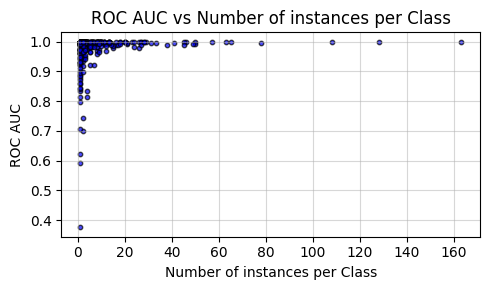

AUC Promedio (filtrando NaN): 0.977
AUC Mediana (filtrando NaN):  0.9969


In [77]:
# Calcular la cantidad de instancias por clase
cantidad_instancias = np.sum(y_val_binarized, axis=0)

# Extraer los valores de roc_auc
roc_values = list(roc_auc.values())

# Filtrar valores NaN antes de calcular promedio y mediana
valid_roc_values = [value for value in roc_values if not np.isnan(value)]

# Crear el gráfico (se mantiene el original, con los NaN si existen)
plt.figure(figsize=(5, 3))
plt.scatter(cantidad_instancias, roc_values, color='blue', alpha=0.7, edgecolor='black', s=10)
plt.title('ROC AUC vs Number of instances per Class')
plt.xlabel('Number of instances per Class')
plt.ylabel('ROC AUC')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

# Calcular e imprimir el AUC Promedio y Mediana solo para valores válidos
if valid_roc_values:
    print(f'AUC Promedio (filtrando NaN): {round(np.average(valid_roc_values),4)}')
    print(f'AUC Mediana (filtrando NaN):  {round(np.median(valid_roc_values),4)}')
else:
    print('No hay valores de AUC válidos para calcular el promedio y la mediana.')